In [ ]:
suppressMessages(library("rwwa"))

# Revised synthesis functions to handle any uncertainty CI

In [211]:
getsynmean_q <- function(data, sig_mod = 0, ci = 0.95) {

  q <- qnorm(1-(1-ci)/2)
  # calculate weight for each model based on inverse variance
  w = 1/(((data$upper - data$lower)/(2*q))^2 + sig_mod^2)
  w1 = sum(w)

  # weighted mean
  s1 <- sum(w*data$est) / w1

  # get weighted interval by adding variances
  sig_lower = sqrt(sum(w * (((data$est - data$lower)/q)^2 + sig_mod^2)) / w1)
  sig_upper = sqrt(sum(w * (((data$est - data$upper)/q)^2 + sig_mod^2)) / w1)

  return(setNames(s1 + c(0, -q*sig_lower, +q*sig_upper), c("est", "lower", "upper")))
}


################################################################################################################################
#' Support function to calculate the chi^2 function used to estimate sig_mod
#'
#' @param data Data.frame with one row per climate model, with columns containing best estimate and upper and lower bound of 95pc confidence interval for the quantity of interest
#' @param sig_mod Scalar: model representation error. Default value is 0
#'
#' @return Vector of best estimate and 95pcconfidence bounds for weighted model mean, with and without model representation error
#'
#' @keywords internal
#' @export
#'
getsynchi2_q <- function(data, sig_mod = 0, ci = 0.95) {

  q <- qnorm(1-(1-ci)/2)
  # function to be minimized by finding sig_mod such that chi^2/mdof ~= 1

  # get best estimate of weighted mean
  s1 <- getsynmean_q(data, sig_mod, ci = ci)["est"]

  # compute chi2 by converting model intervals to standard deviations & adding sig_mod adjustment
  chi2 <- sum(apply(data[,c("est", "lower", "upper")], 1, function(x) {
    if(x["est"] > s1) {
      (x["est"] - s1)^2 / (((x["est"] - x["lower"])/q)^2 + sig_mod^2)
    } else {
      (x["est"] - s1)^2 / (((x["est"] - x["upper"])/q)^2 + sig_mod^2)
    }
  }))
  return(chi2)
}


################################################################################################################################
#' Produce synthesis of attribution results from observations and climate models
#'
#' @param obs_in Data.frame with one row per observational dataset, with columns "est", "lower" and "upper" giving the best estimate and lower and upper bounds for the quantity of interest. Dataset names should be given as rownames. Default is NA (no observations), in which case only the model synthesis is carried out.
#' @param models_in Data.frame with one row per climate model, with columns "est", "lower" and "upper" giving the best estimate and lower and upper bounds for the quantity of interest. Model names should be given as rownames.
#' @param synth_type String defining the type of synthesis to carry out. Options are 'abs' (absolute changes); 'rel' (percentage changes); and 'PR' (probability ratios). Default is 'abs'.
#'
#' @return List containing synth_type; sig_obs (scalar value indicating obs representation error); sig_mod (scalar value indicating model representation error); chi2/dof (initial estimate of ratio of chi^2 to model DOF); and df, a data.frame containing the synthesised results.
#'
#' @export
#'
synthesis_q <- function(obs_in = NA, models_in, synth_type = "abs", ci = 0.95) {

  q <- qnorm(1-(1-ci)/2)
    
  if(is.na(unlist(obs_in))[1]) {
    no_obs <- T
    # create a dummy dataframe to avoid having to rewrite everything twice
    obs_in <- data.frame("est" = 0, "lower" = 0, "upper" = 0)
    rownames(obs_in) <- "dummy"
  } else {
    no_obs <- F
  }

  # relabel the data for easier reference later
  colnames(obs_in) <- colnames(models_in) <- c("est", "lower", "upper")

  if(!("model" %in% colnames(obs_in))) obs_in$model <- rownames(obs_in)
  if(!("model" %in% colnames(models_in))) models_in$model <- rownames(models_in)

  #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

  if(!synth_type %in% c("abs", "rel", "PR")) {
    cat(paste0("Synthesis type '",synth_type,"' not implemented - must be abs, rel or PR"), "\n")
  }

  if(synth_type == "PR") {
    obs_in[,c("est", "lower", "upper")] <- log(obs_in[,c("est", "lower", "upper")])
    models_in[,c("est", "lower", "upper")] <- log(models_in[,c("est", "lower", "upper")])
  } else if(synth_type == "rel") {
    obs_in[,c("est", "lower", "upper")] <- log(1+obs_in[,c("est", "lower", "upper")]/100)
    models_in[,c("est", "lower", "upper")] <- log(1+models_in[,c("est", "lower", "upper")]/100)
  }

  #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  # get mean of intervals to estimate natural variability component

  # compute representation error from scatter of mean ($\sigma_{rep}$ in the paper)
  nobs = nrow(obs_in)
  obs <- apply(obs_in[,c("est", "lower", "upper"),drop = F], 2, mean)
  if(nobs == 1) {
    sig_obs = 0
  } else {
    s2 = sum((obs_in$est - obs[1])^2)
    sig_obs = sqrt(s2/(nobs-1))
  }

  # add representation error to individual observations
  obs_in$l_wb <- obs_in$est - sqrt((obs_in$est - obs_in$lower)**2 + (q*sig_obs)**2)
  obs_in$u_wb <- obs_in$est + sqrt((obs_in$est - obs_in$upper)**2 + (q*sig_obs)**2)

  # apply representation error to obs synthesis
  # we're working with confidence intervals here, so we extend them by adding (qsig_obs)^2 in quadrature
  obs[2] <- obs[1] - sqrt( (obs[1] - obs[2])**2 + (q*sig_obs)**2 )
  obs[3] <- obs[1] + sqrt( (obs[1] - obs[3])**2 + (q*sig_obs)**2 )

  #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  # get initial estimate of model mean & calculate chi^2
  chi2 <- getsynchi2_q(models_in, sig_mod = 0, ci = ci)
  mdof <- nrow(models_in)-1

  if ( chi2/mdof > 1 ) {
    # find sig_mod such that chi^2/dof = 1
    sig_mod <- optim(0, function(x) {(getsynchi2_q(models_in, sig_mod = x, ci = ci) - (nrow(models_in)-1))^2},
                     method = "Brent", lower = 0, upper = 5)$par
  } else {
    sig_mod <- 0
  }

  # get weighted model mean
  models <- getsynmean_q(models_in, sig_mod = sig_mod, ci = ci)

  # add representation error to individual models
  models_in$l_wb <- models_in$est - sqrt((models_in$est - models_in$lower)**2 + (q*sig_mod)**2)
  models_in$u_wb <- models_in$est + sqrt((models_in$est - models_in$upper)**2 + (q*sig_mod)**2)

  #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  # weighted mean of models & obs (coloured bar)
  w_obs <- unname((obs["upper"] - obs["lower"])^{-2})
  w_mod <- unname((models["upper"] - models["lower"])^{-2})

  wmean <- (w_obs * obs["est"] + w_mod * models["est"]) / (w_obs + w_mod)

  # get weighted interval by averaging variances
  sig_lower = sqrt((w_obs * ((obs["est"] - obs["lower"])/q)^2 + w_mod * ((models["est"] - models["lower"])/q)^2) / (w_obs + w_mod))
  sig_upper = sqrt((w_obs * ((obs["est"] - obs["upper"])/q)^2 + w_mod * ((models["est"] - models["upper"])/q)^2) / (w_obs + w_mod))
  synth <- setNames(c(wmean, wmean - q*sig_lower, wmean + q*sig_upper), c("est", "lower", "upper"))

  # unweighted mean of obs and models
  umean <- (obs["est"] +  models["est"]) / 2
  synth["l_wb"] <- umean - sqrt(((obs["est"]-obs["lower"])^2 + (models["est"]-models["lower"])^2)/2)
  synth["u_wb"] <- umean + sqrt(((obs["est"]-obs["upper"])^2 + (models["est"]-models["upper"])^2)/2)

  #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  # add group labels for easier plotting
  obs_in <- cbind(obs_in, "group" = "obs")
  obs <- data.frame(t(c("model" = "Observations", "group" = "obs_synth", obs)))
  models_in <- cbind(models_in, "group" = "models")
  models <- data.frame(t(c("model" = "Models", "group" = "model_synth", models)))
  synth <- data.frame(t(c("model" = "Synthesis", "group" = "synth", synth)))

  # combine all the data together in one dataframe
  res <- rbind.fill(obs_in, obs, models_in, models, synth)[,c("group", "model", "est", "lower", "upper", "l_wb", "u_wb")]
  for(cnm in c("est", "lower", "upper", "l_wb", "u_wb")) { res[,cnm] <- as.numeric(res[,cnm]) }

  # if only dummy obs, remove
  if(no_obs) {
    # drop all rows that don't relate to models
    res <- res[grepl("model", res$group),]
    sig_obs <- NA
  }

  #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  # reverse any transformations applied
  if(synth_type == "PR") {
    res[,c("est", "lower", "upper", "l_wb", "u_wb")] <- exp(res[,c("est", "lower", "upper", "l_wb", "u_wb")])
    sig_obs <- exp(sig_obs)
    sig_mod <- exp(sig_mod)
    umean <- exp(umean)
  } else if(synth_type == "rel") {
    res[,c("est", "lower", "upper", "l_wb", "u_wb")] <- 100*(exp(res[,c("est", "lower", "upper", "l_wb", "u_wb")])-1)
    sig_obs <- 100*(exp(sig_obs)-1)
    sig_mod <- 100*(exp(sig_mod)-1)
    umean <- 100*(exp(umean)-1)
  }

  return(list(synth_type = synth_type, sig_obs = sig_obs, "chi2/dof" = chi2 / mdof, sig_mod = sig_mod, df = res, uw_mean = umean))
}

# Check results

In [212]:
q75 <- read.csv("synth_FWI95_chilean_temperate_forests_and_matorral_attr_dI_rel_25th-75th.csv")
q95 <- read.csv("synth_FWI95_chilean_temperate_forests_and_matorral_attr_dI_rel_5th-95th.csv")

res <- merge(q75, q95, by = c("X", "group", "model", "est"), suffixes = c("_q75", "_q95"))

NULL

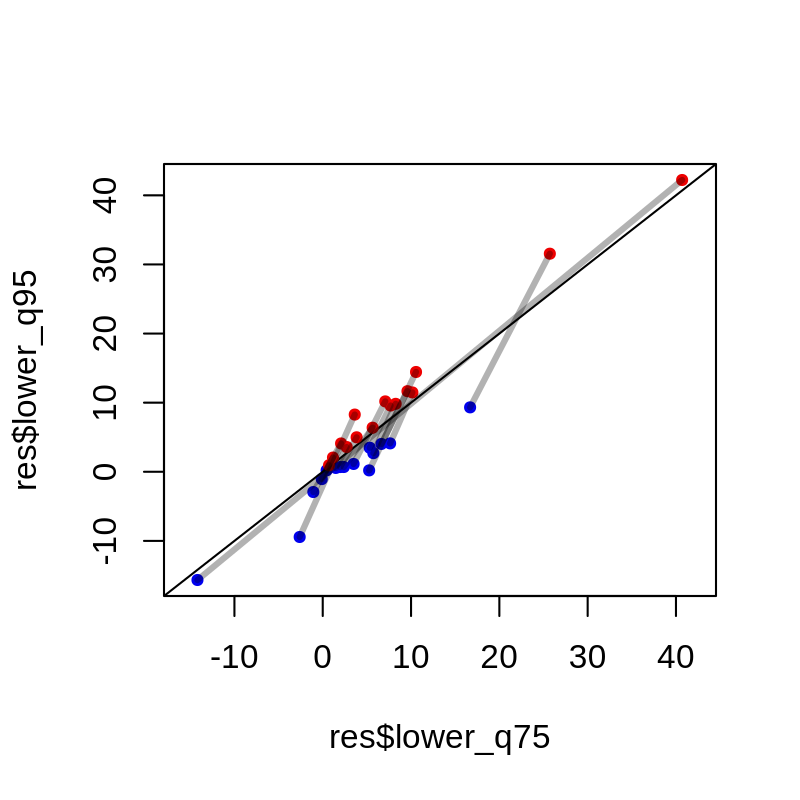

In [213]:
# quick visual check of bouunds

prep_window(c(1,1))

rng <- range(c(res$lower_q95, res$upper_q95))

plot(res$lower_q75, res$lower_q95, ylim = rng, xlim = rng, col = "blue2"); abline(0,1)
points(res$upper_q75, res$upper_q95, col = "red2")

apply(res, 1, function(r) lines(c(r["lower_q75"], r["upper_q75"]), c(r["lower_q95"], r["upper_q95"]), col = adjustcolor("black", 0.3), lwd = 3))

# Modified synthesis

In [214]:
q75 <- read.csv("synth_FWI95_chilean_temperate_forests_and_matorral_attr_dI_rel_25th-75th.csv")
q95 <- read.csv("synth_FWI95_chilean_temperate_forests_and_matorral_attr_dI_rel_5th-95th.csv")

res <- merge(q75, q95, by = c("X", "group", "model", "est"), suffixes = c("_q75", "_q95"))

In [215]:
obs_q75 <- res[res$group == "obs",3:6]
obs_q95 <- res[res$group == "obs",c(3:4,9:10)]
rownames(obs_q75) <- rownames(obs_q95) <- obs_q75[,1]

mdl_q75 <- res[res$group == "models",3:6]
mdl_q95 <- res[res$group == "models",c(3:4,9:10)]
rownames(mdl_q75) <- rownames(mdl_q95) <- mdl_q75[,1]

In [216]:
synth_org <- synthesis(obs_q95[,-1], mdl_q95[,-1], synth_type = "rel")
synth_q95 <- synthesis_q(obs_q95[,-1], mdl_q95[,-1], synth_type = "rel", ci = 0.95)
synth_q75 <- synthesis_q(obs_q75[,-1], mdl_q75[,-1], synth_type = "rel", ci = 0.75)

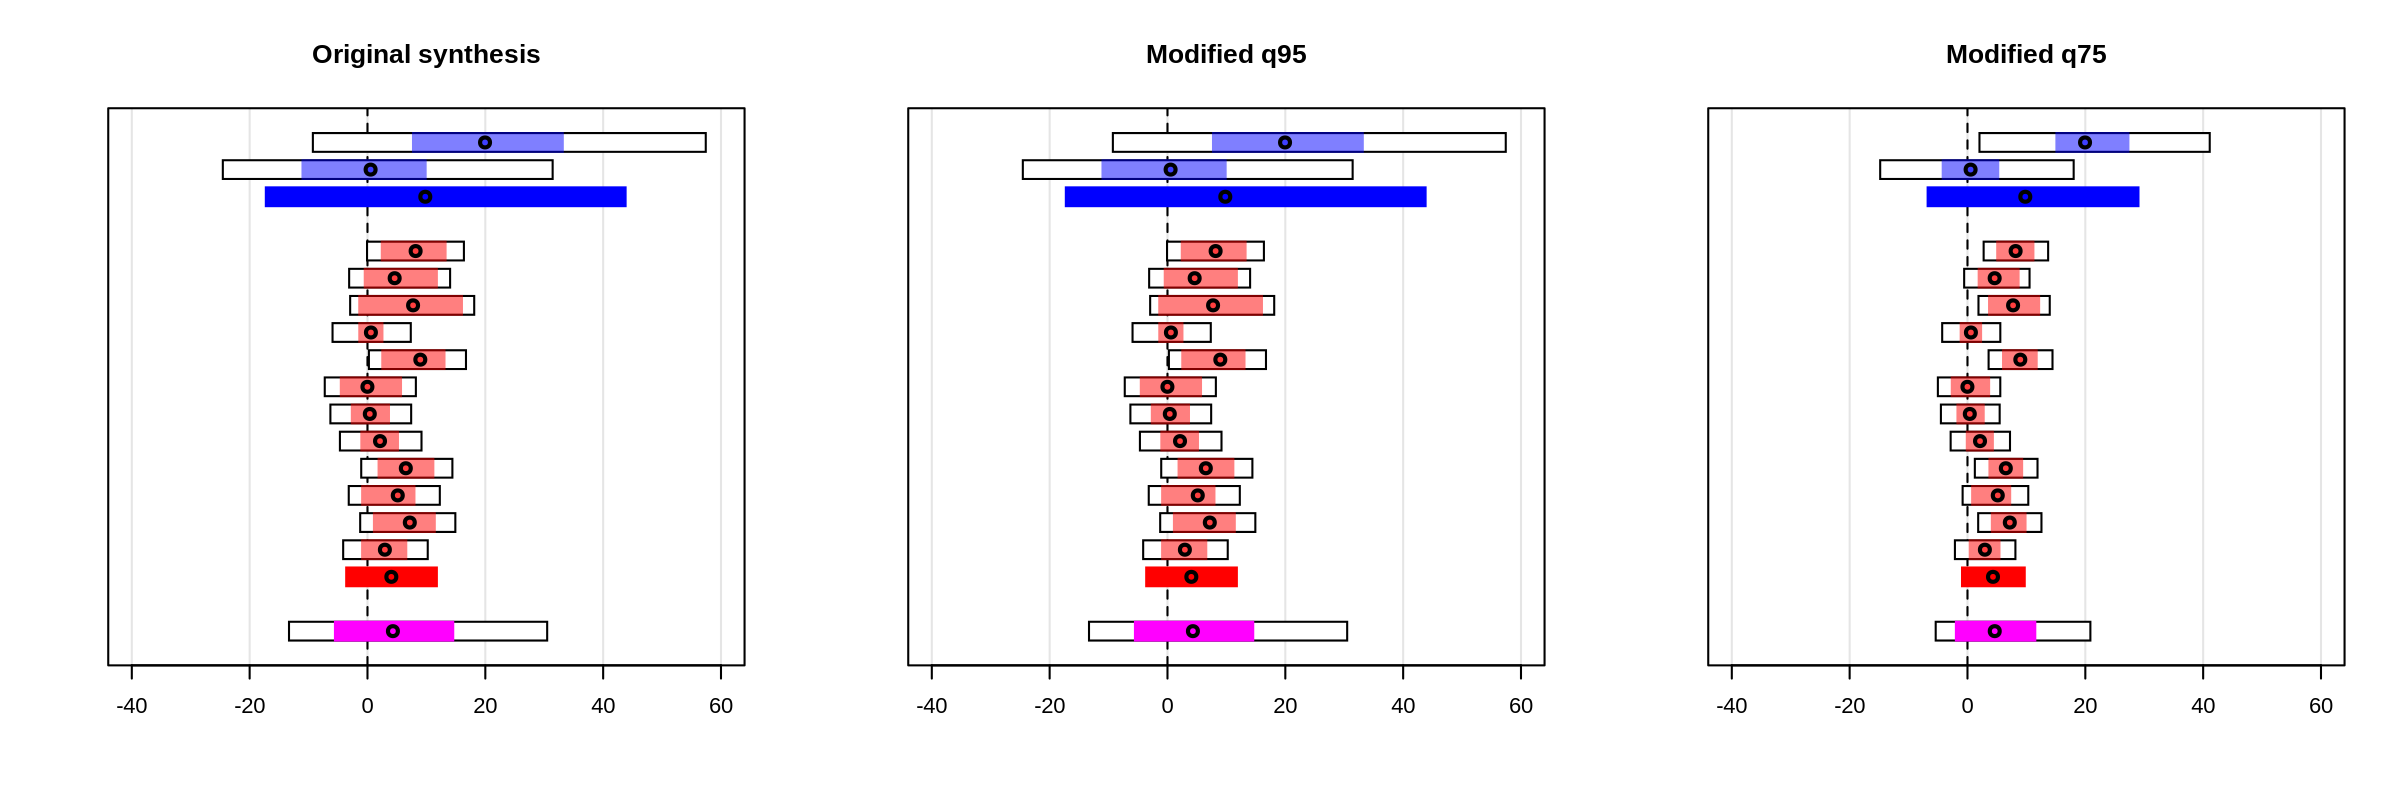

In [217]:
prep_window(c(1,3))

xlim <- c(-40,60)
plot_synthesis(synth_org, hide_labels = T, xlim = xlim, main = "Original synthesis")
plot_synthesis(synth_q95, hide_labels = T, xlim = xlim, main = "Modified q95")
plot_synthesis(synth_q75, hide_labels = T, xlim = xlim, main = "Modified q75")

# Synthesise all results


In [219]:
fl <- list.files("synth_in", full.names = T)

for(fnm in fl) {
    new_fnm <- paste0("synth_out/", basename(fnm))
    if(file.exists(new_fnm)) next

    ci <- as.numeric(gsub("th.csv","",strsplit(fnm, "th-")[[1]][2]))/100
    if(grepl("_pr_", fnm)) stype <- "PR" else stype <- "rel"
    
    df <- read.csv(fnm, row.names = "model")

    if("obs" %in% df$group) obs <- df[df$group == "obs", c("est", "lower", "upper")] else obs <- NA
    models <- df[df$group == "models", c("est", "lower", "upper")]

    synth <- synthesis_q(obs = obs, models = models, synth_type = stype, ci = ci)
    write.csv(synth$df, new_fnm, row.names = F)
}